In [2]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [4]:
keys = 'u', 'v', 'w', 'p_total'


def extract(real, keys):
    data = []
    with h5py.File("/data1/dataToYouri/couette_dns_ml_f32.h5", 'r') as f:
        for k in keys:
            data.append(np.array(f[real][k]))
        return np.stack(data, axis=1)

        
def domain():
    data = {}
    keys = ['x', 'y', 'z']
    with h5py.File("/data1/dataToYouri/couette_dns_ml_f32.h5", 'r') as f:
        for k in keys:
            data[k] = np.array(f[k])
        return data

        
d = extract('R3', keys)[::100]
domain = domain()
dx = domain['x'][1] - domain['x'][0]
dz = domain['z'][1] - domain['z'][0]
nx = domain['x'].shape[0]
nz = domain['z'].shape[0]
y = domain['y']

In [7]:
d_hat = np.fft.fft2(d, axes=(2, 4))

In [8]:
d_hat.shape

(49, 4, 24, 33, 24)

In [26]:
wall_pressure_hat = d_hat[:, 3, :, 0]

In [27]:
wall_pressure_hat.shape

(49, 24, 24)

In [40]:
kx = 0
kz = 5
y_idx = 1
comp = 0
# kx 0, kz 5, y_idx 1, u, should have high coherence to wall pressure
velocity_target = d_hat[:, comp, kx, y_idx, kz]

In [41]:
velocity_target.shape

(49,)

In [42]:
pressure_target = wall_pressure_hat[:, kx, kz]

In [43]:
pressure_target.shape

(49,)

In [68]:
def cross_spectrum(p_hat, u_hat, avg_axis=(0,)):
    return np.mean(p_hat.conj() * u_hat, axis=avg_axis) - (np.mean(p_hat, axis=avg_axis).conj() * np.mean(u_hat, axis=avg_axis))
    


[]

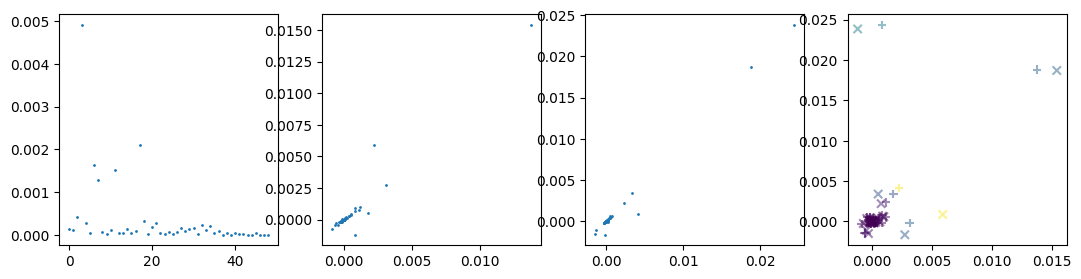

In [69]:

Spu = cross_spectrum(pressure_target, velocity_target)
Spp = cross_spectrum(pressure_target, pressure_target)
H = Spu / Spp
pressure_scaled = pressure_target * H
distances = np.abs(pressure_scaled - velocity_target)

fig, ax = plt.subplots(1, 4, figsize=(13, 3))
ax[0].scatter(np.arange(len(distances)), distances, s=1)
ax[1].scatter(pressure_scaled.real, velocity_target.real, s=1)
ax[2].scatter(pressure_scaled.imag, velocity_target.imag, s=1)
ax[3].scatter(pressure_scaled.real, pressure_scaled.imag, c=distances, marker='+', alpha=0.5)
ax[3].scatter(velocity_target.real, velocity_target.imag, c=distances, marker='x', alpha=0.5)
plt.plot()

In [93]:
def plot_rel(d_hat, kx, kz, y_idx, comp):
    wall_pressure_hat = d_hat[:, 3, :, 0]
    pressure_target = wall_pressure_hat[:, kx, kz]
    velocity_target = d_hat[:, comp, kx, y_idx, kz]
    
    Spu = cross_spectrum(pressure_target, velocity_target)
    Spp = cross_spectrum(pressure_target, pressure_target)
    H = Spu / Spp
    pressure_scaled = pressure_target * H
    distances = np.abs(pressure_scaled - velocity_target)
    
    fig, ax = plt.subplots(1, 4, figsize=(13, 3))
    ax[0].scatter(np.arange(len(distances)), distances, s=1)
    ax[1].scatter(pressure_scaled.real, velocity_target.real, s=1)
    ax[2].scatter(pressure_scaled.imag, velocity_target.imag, s=1)
    ax[3].scatter(pressure_scaled.real, pressure_scaled.imag, c=distances, marker='+', alpha=0.5)
    sc = ax[3].scatter(velocity_target.real, velocity_target.imag, c=distances, marker='x', alpha=0.5)
    ax[0].set_title('distance vs sample index')
    ax[1].set_title('real: prediction vs actual')
    ax[2].set_title('imag: prediction vs actual')
    ax[3].set_title('complex plane')
    fig.colorbar(sc, ax=ax[3], label='distance')
    fig.suptitle(f'comp={["u", "v", "w"][comp]} kx={kx}, kz={kz}, y_idx={y_idx}  (γ²={np.abs(Spu)**2/(Spp*np.mean(np.conj(velocity_target)*velocity_target)).real:.3f})')
    plt.tight_layout()
    plt.plot()

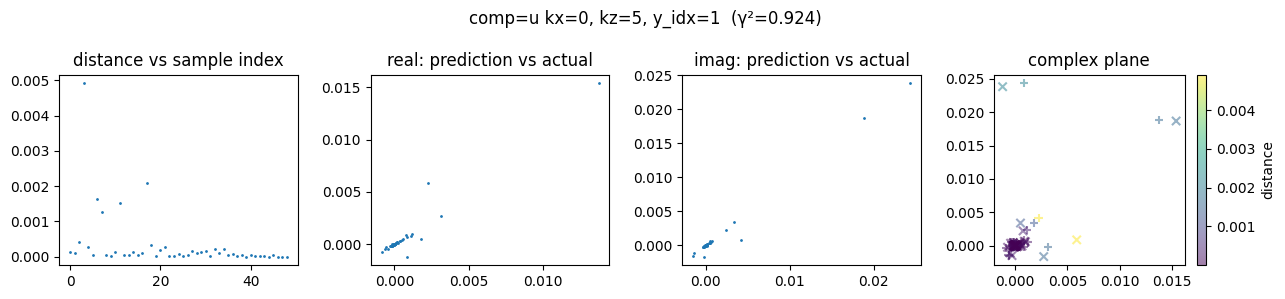

In [94]:
plot_rel(d_hat, 0, 5, 1, 0)

In [97]:
from ipywidgets import interact, IntSlider
@interact(
    comp=IntSlider(min=0, max=2, step=1, value=0, description="Component"),
    kx=IntSlider(min=0, max=d_hat.shape[2] - 1, step=1, value=0, description="kx"),
    y_idx=IntSlider(min=0, max=d_hat.shape[3] - 1, step=1, value=0, description="y idx"),
    kz=IntSlider(min=0, max=d_hat.shape[4] - 1, step=1, value=0, description="kz"),
)
def plot(kx, kz, y_idx, comp):
    plot_rel(d_hat, kx, kz, y_idx, comp)

interactive(children=(IntSlider(value=0, description='kx', max=23), IntSlider(value=0, description='kz', max=2…